In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
data = {
    "engine_size": [
        1.2, 1.5, 2.0, np.nan, 1.8,
        1.3, 2.5, 1.6, 2.0, 1.4,
        1.8, 2.2, np.nan, 1.5, 2.0,
        1.3, 2.4, 1.7, 1.5, 2.0
    ],

    "mileage": [
        45000, 30000, 20000, 60000, np.nan,
        50000, 15000, 35000, 25000, 55000,
        40000, 18000, 70000, 32000, 22000,
        65000, 12000, np.nan, 45000, 28000
    ],

    "age": [
        5, 3, 2, 7, 4,
        np.nan, 1, 3, 2, 6,
        4, 2, 8, 3, 2,
        7, 1, 5, np.nan, 3
    ],

    "fuel_type": [
        "Petrol", "Diesel", "Petrol", "Hybrid",
        "Petrol", "Diesel", "Hybrid", "Petrol",
        np.nan, "Diesel", "Petrol", "Hybrid",
        "Diesel", "Petrol", "Hybrid", "Diesel",
        "Petrol", "Hybrid", "Diesel", "Petrol"
    ],

    "transmission": [
        "Manual", "Automatic", "Automatic", "Automatic",
        "Manual", "Manual", "Automatic", "Manual",
        "Automatic", np.nan, "Manual", "Automatic",
        "Manual", "Automatic", "Automatic", "Manual",
        "Automatic", "Manual", "Automatic", "Manual"
    ],

    "resale_price": [
        2200000, 3000000, 4500000, 2700000, 3500000,
        2100000, 5200000, 2800000, 4000000, 2300000,
        3100000, 4800000, 1800000, 2900000, 4300000,
        2000000, 5500000, 3200000, 2600000, 3900000
    ]
}

df = pd.DataFrame(data)

df

,engine_size,mileage,age,fuel_type,transmission,resale_price
0,1.2,45000.0,5.0,Petrol,Manual,2200000
1,1.5,30000.0,3.0,Diesel,Automatic,3000000
2,2.0,20000.0,2.0,Petrol,Automatic,4500000
3,NaN,60000.0,7.0,Hybrid,Automatic,2700000
4,1.8,NaN,4.0,Petrol,Manual,3500000
5,1.3,50000.0,NaN,Diesel,Manual,2100000
6,2.5,15000.0,1.0,Hybrid,Automatic,5200000
7,1.6,35000.0,3.0,Petrol,Manual,2800000
8,2.0,25000.0,2.0,NaN,Automatic,4000000
9,1.4,55000.0,6.0,Diesel,NaN,2300000


In [3]:
X = df.drop("resale_price", axis=1)

Y = df["resale_price"]

In [4]:
print("X:")
print(X)

print("\nY:")
print(Y)

X:
    engine_size  mileage  age fuel_type transmission
0           1.2  45000.0  5.0    Petrol       Manual
1           1.5  30000.0  3.0    Diesel    Automatic
2           2.0  20000.0  2.0    Petrol    Automatic
3           NaN  60000.0  7.0    Hybrid    Automatic
4           1.8      NaN  4.0    Petrol       Manual
5           1.3  50000.0  NaN    Diesel       Manual
6           2.5  15000.0  1.0    Hybrid    Automatic
7           1.6  35000.0  3.0    Petrol       Manual
8           2.0  25000.0  2.0       NaN    Automatic
9           1.4  55000.0  6.0    Diesel          NaN
10          1.8  40000.0  4.0    Petrol       Manual
11          2.2  18000.0  2.0    Hybrid    Automatic
12          NaN  70000.0  8.0    Diesel       Manual
13          1.5  32000.0  3.0    Petrol    Automatic
14          2.0  22000.0  2.0    Hybrid    Automatic
15          1.3  65000.0  7.0    Diesel       Manual
16          2.4  12000.0  1.0    Petrol    Automatic
17          1.7      NaN  5.0    Hybrid    

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [6]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)

X_train: (16, 5)
X_test : (4, 5)
Y_train: (16,)
Y_test : (4,)


In [7]:
numeric_features = [
    "engine_size",
    "mileage",
    "age"
]

categorical_features = [
    "fuel_type",
    "transmission"
]

In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [9]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),

    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [11]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

In [12]:
model.fit(X_train, Y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [14]:
predictions = model.predict(X_test)

print(predictions)

[1981798.61905927 3117555.53590904 1329496.71901757 3165166.05887163]


In [15]:
comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": predictions
})

comparison

,Actual,Predicted
0,2200000,1.981799e+06
1,3200000,3.117556e+06
2,2000000,1.329497e+06
3,3000000,3.165166e+06


In [16]:
r2 = r2_score(Y_test, predictions)

print("R²:", r2)

R²: 0.4891697989278023


In [17]:
mae = mean_absolute_error(
    Y_test,
    predictions
)

print("MAE:", mae)

MAE: 284078.7962214396


In [18]:
mse = mean_squared_error(
    Y_test,
    predictions
)

print("MSE:", mse)


MSE: 132815852278.7714


In [19]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 364439.0926873397


In [21]:
cv_scores = cross_val_score(
    model,
    X,
    Y,
    cv=5,
    scoring="r2"
)

print(cv_scores)

[0.95450941 0.97058719 0.9732911  0.8857476  0.92680869]


In [23]:
mean_cv=cv_scores.mean()
print("Mean Cv",mean_cv)


Mean Cv 0.9421888003672839


In [24]:
std_cv = cv_scores.std()

print("CV Standard Deviation:", std_cv)

CV Standard Deviation: 0.03270405361872593


In [26]:
print("========== CROSS-VALIDATION ==========")

print("Fold Scores:", cv_scores)

print("Mean R²:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

========== CROSS-VALIDATION ==========
Fold Scores: [0.95450941 0.97058719 0.9732911  0.8857476  0.92680869]
Mean R²: 0.9421888003672839
Standard Deviation: 0.03270405361872593


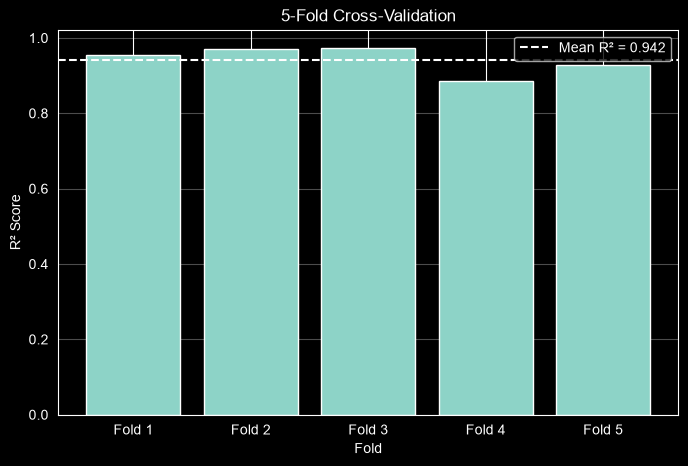

In [27]:
plt.figure(figsize=(8, 5))

folds = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5"
]

plt.bar(
    folds,
    cv_scores
)

plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    label=f"Mean R² = {cv_scores.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("R² Score")
plt.title("5-Fold Cross-Validation")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

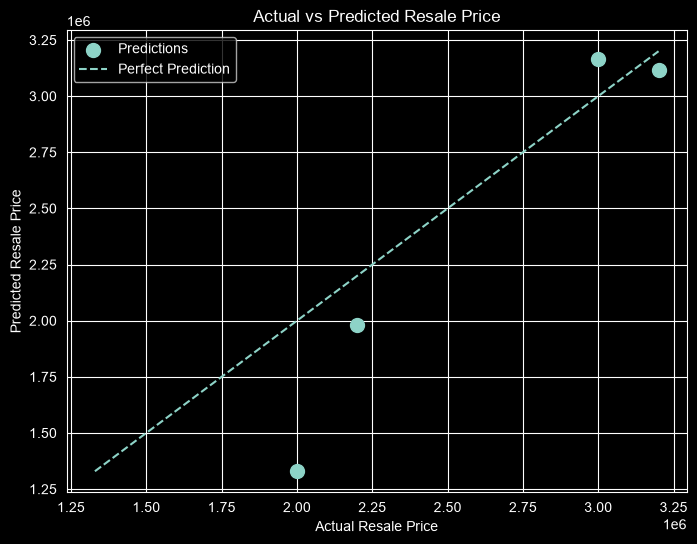

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(
    Y_test,
    predictions,
    s=100,
    label="Predictions"
)

minimum = min(
    Y_test.min(),
    predictions.min()
)

maximum = max(
    Y_test.max(),
    predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Resale Price")
plt.ylabel("Predicted Resale Price")

plt.title("Actual vs Predicted Resale Price")

plt.legend()
plt.grid(True)

plt.show()

In [29]:
residuals = Y_test.values - predictions

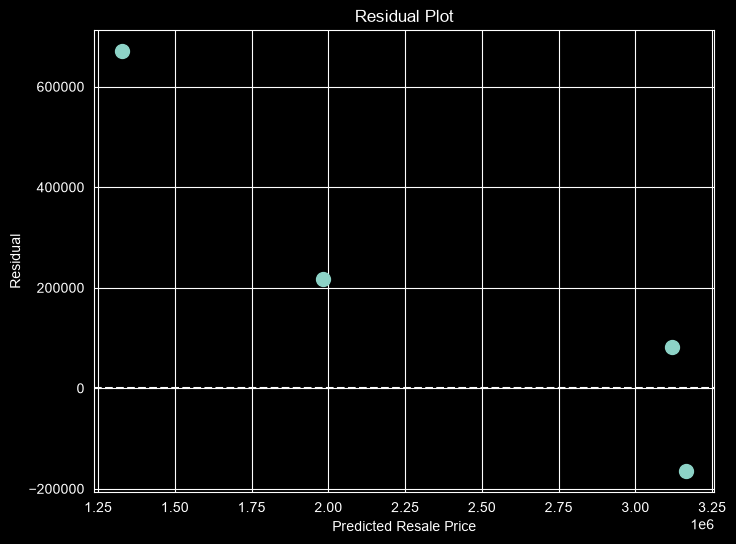

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    predictions,
    residuals,
    s=100
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Resale Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [32]:
from sklearn.model_selection import KFold
kfold=KFold(
    n_splits=5,
    random_state=42

)

In [33]:
for fold, (train_index, test_index) in enumerate(
    kfold.split(X),
    start=1
):

    print(f"Fold {fold}")
    print("Training indexes:", train_index)
    print("Testing indexes :", test_index)
    print()

Fold 1
Training indexes: [ 2  3  4  5  6  7  8  9 10 11 12 13 14 16 18 19]
Testing indexes : [ 0  1 15 17]

Fold 2
Training indexes: [ 0  1  2  4  6  7  9 10 12 13 14 15 16 17 18 19]
Testing indexes : [ 3  5  8 11]

Fold 3
Training indexes: [ 0  1  3  4  5  6  7  8  9 10 11 12 14 15 17 19]
Testing indexes : [ 2 13 16 18]

Fold 4
Training indexes: [ 0  1  2  3  5  6  7  8 10 11 13 14 15 16 17 18]
Testing indexes : [ 4  9 12 19]

Fold 5
Training indexes: [ 0  1  2  3  4  5  8  9 11 12 13 15 16 17 18 19]
Testing indexes : [ 6  7 10 14]



In [34]:
from sklearn.metrics import r2_score

fold_scores = []

for fold, (train_index, test_index) in enumerate(
    kfold.split(X),
    start=1
):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    Y_train_fold = Y.iloc[train_index]
    Y_test_fold = Y.iloc[test_index]

    model.fit(
        X_train_fold,
        Y_train_fold
    )

    predictions_fold = model.predict(
        X_test_fold
    )

    score = r2_score(
        Y_test_fold,
        predictions_fold
    )

    fold_scores.append(score)

    print(
        f"Fold {fold} R²: {score:.4f}"
    )

Fold 1 R²: 0.4892
Fold 2 R²: 0.9801
Fold 3 R²: 0.8965
Fold 4 R²: 0.9143
Fold 5 R²: 0.9230


In [35]:
mean_score = np.mean(fold_scores)

print("Mean Cross-Validation R²:", mean_score)

Mean Cross-Validation R²: 0.8406111985033841


In [36]:
mean_score = np.mean(fold_scores)

print("Mean Cross-Validation R²:", mean_score)

Mean Cross-Validation R²: 0.8406111985033841


In [37]:
std_score = np.std(fold_scores)

print("Standard Deviation:", std_score)

Standard Deviation: 0.1779332237062466
